#### What is Parallelization in LangGraph?
In LangGraph, nodes typically execute in a sequence defined by edges, but when tasks don’t depend on each other’s outputs, you can run them in parallel. This is achieved by:
- Defining multiple nodes that can operate independently.

- Connecting them to a common starting point (e.g., START or another node).

- Merging their outputs into a downstream node if needed.

LangGraph handles this implicitly when nodes are independent and can leverage multi-threading or asynchronous execution under the hood, depending on the runtime environment (e.g., Python’s asyncio or a multi-threaded executor).

In [1]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_PROJECT"]=os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"]="true"

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3.6-27b")
llm

d:\OneDrive - Maarga Systems Private Limited\Documents\Agentic-AI-BridgeCourse\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, client=<groq.resources.chat.completions.Completions object at 0x0000018E9CFAC380>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018E9E2D9760>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    topic:str
    characters:str
    settings:str
    premises:str
    story_intro:str

In [4]:
def generate_character(state:State):
     """Generate character descriptions"""
     msg=llm.invoke(f"Create two character names and brief traits for a story about {state['topic']}")
     return {"characters":msg.content}

def generate_settings(state:State):
     """Generate a story setting"""
     msg=llm.invoke(f"Describe a vivid setting for a story about {state['topic']}")
     return {"settings":msg.content}

def generate_premises(state:State):
     """Generate a story premise"""
     msg=llm.invoke(f"Write a one-sentence plot premise for a story about {state['topic']}")
     return {"premises":msg.content}

def combine_elements(state:State):
     """Combine characters, setting, and premise into an intro"""
     msg=llm.invoke(f"Write a short story introduction using these elements:\n"
        f"Characters: {state['characters']}\n"
        f"Setting: {state['settings']}\n"
        f"Premise: {state['premises']}")
     return {"story_intro":msg.content}

In [5]:
graph = StateGraph(State)
graph.add_node("generate_character", generate_character)
graph.add_node("generate_settings", generate_settings)
graph.add_node("generate_premises", generate_premises)
graph.add_node("combine_elements", combine_elements)

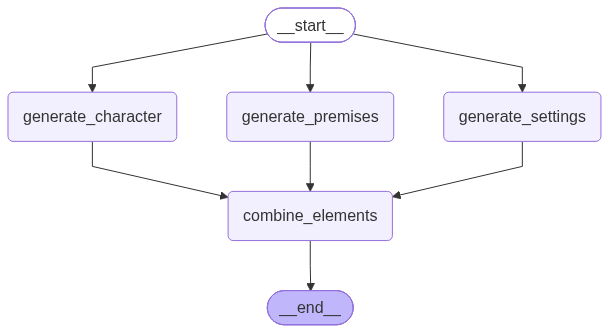

In [6]:
graph.add_edge(START, "generate_character")
graph.add_edge(START, "generate_settings")
graph.add_edge(START, "generate_premises")

graph.add_edge("generate_character", "combine_elements")
graph.add_edge("generate_settings", "combine_elements")
graph.add_edge("generate_premises", "combine_elements")
graph.add_edge("combine_elements", END)

compiled_graph = graph.compile()
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [7]:
compiled_graph.invoke({"topic":"friends"})


{'topic': 'friends',
 'characters': '\n<think>\nHere\'s a thinking thinking sequence\n\n1.  **Deconstruct the user\'s request:**\n    *   Goal: Create two character names and brief traits.\n    *   Context: A story about friends.\n    *   Implicit/Explicit needs: Names should sound good together, traits should suggest a dynamic (complementary or contrasting), and the output should be concise ("brief traits").\n\n2.  **Brainstorming Core Concepts/Dynamics:**\n    *   *I A:* Best friends since childhood. One is the planner, one is the risk-taker.\n    *   *I B:* Friends who meet by chance. One is cynical, one is optimistic.\n    *   *I C:* Friends with a secret. One is protective, one is reckless.\n    *   *Decision:* I should provide a pair that offers a clear dynamic, as that\'s usually most helpful for a writer. I\'ll go with a classic "Opposites Attract/Complementary" dynamic, as it creates immediate tension and bonding opportunities. Let\'s aim for: *Grounded/Practical* vs. *Whimsic

#### Key Benefits
- Speed: Reduces total execution time by running tasks concurrently.

- Scalability: Handles larger workflows efficiently.

- Modularity: Keeps the graph structure clean and reusable.

#### Key Takeaways
- When to Parallelize: Use it for independent tasks (e.g., generating multiple outputs, checking separate inputs).

- Merging: Downstream nodes can aggregate parallel results.

- LangGraph Support: The framework naturally supports this by waiting for all required inputs before proceeding.
